## SKEWED DATA

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../Data/Placement.csv")

In [2]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [3]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

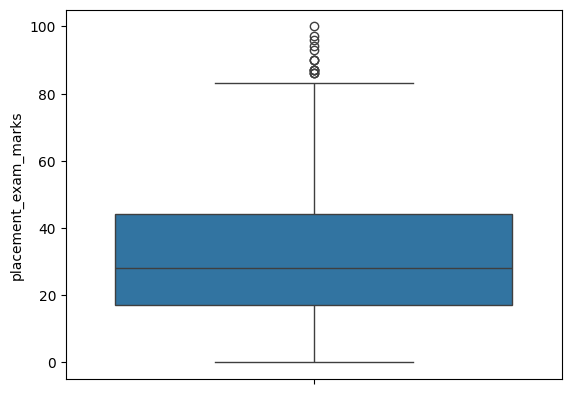

In [4]:
import seaborn as sns

sns.boxplot(df['placement_exam_marks'])

In [6]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

iqr = percentile75 - percentile25

In [7]:
upper_fence = percentile75 + 1.5*iqr
lower_fence = percentile25 - 1.5*iqr

In [8]:
upper_fence , lower_fence

(np.float64(84.5), np.float64(-23.5))

In [12]:
new_df = df[df['placement_exam_marks'] < upper_fence]

<Axes: ylabel='placement_exam_marks'>

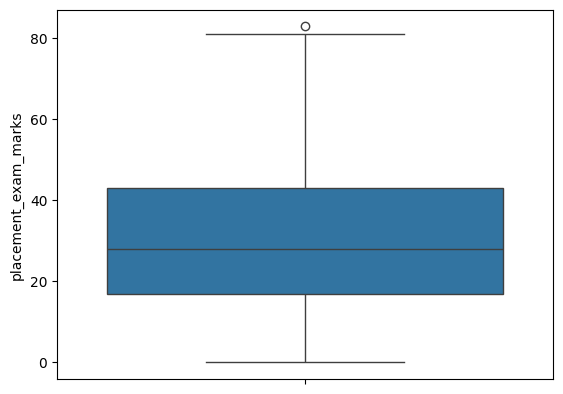

In [13]:
sns.boxplot(new_df['placement_exam_marks'])

In [14]:
new_df_cap = df.copy()

In [16]:
new_df_cap['placement_exam_marks'] = np.where(new_df_cap['placement_exam_marks'] > upper_fence , upper_fence , np.where(new_df_cap['placement_exam_marks']<lower_fence , lower_fence , new_df_cap['placement_exam_marks']))

In [17]:
new_df_cap.shape

(1000, 3)